# Decision Tree Regressor

In [37]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, accuracy_score, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

In [38]:
df = pd.read_csv("../datasets/laptop_eda.csv")
df.head()

,Company,Type,OpSys,CPU,GPU,Ram,Weight,Touchscreen,ClockSpeed,HDD,SSD,PPI,Price
0,Apple,Ultrabook,Mac,Intel,Intel,8,1.37,0,2.3,0.0,0.128,312.781955,71378.6832
1,Apple,Ultrabook,Mac,Intel,Intel,8,1.34,0,1.8,0.0,0.000,175.939850,47895.5232
2,HP,Notebook,No,Intel,Intel,8,1.86,0,2.5,0.0,0.256,192.307692,30636.0000
3,Apple,Ultrabook,Mac,Intel,AMD,16,1.83,0,2.7,0.0,0.512,303.896104,135195.3360
4,Apple,Ultrabook,Mac,Intel,Intel,8,1.37,0,3.1,0.0,0.256,312.781955,96095.8080


## inspect the dataset

In [39]:
df.shape

(1300, 13)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1300 non-null   str    
 1   Type         1300 non-null   str    
 2   OpSys        1300 non-null   str    
 3   CPU          1300 non-null   str    
 4   GPU          1300 non-null   str    
 5   Ram          1300 non-null   int64  
 6   Weight       1300 non-null   float64
 7   Touchscreen  1300 non-null   int64  
 8   ClockSpeed   1300 non-null   float64
 9   HDD          1300 non-null   float64
 10  SSD          1300 non-null   float64
 11  PPI          1300 non-null   float64
 12  Price        1300 non-null   float64
dtypes: float64(6), int64(2), str(5)
memory usage: 132.2 KB


In [41]:
df.isnull().sum()

Company        0
Type           0
OpSys          0
CPU            0
GPU            0
Ram            0
Weight         0
Touchscreen    0
ClockSpeed     0
HDD            0
SSD            0
PPI            0
Price          0
dtype: int64

In [42]:
# To see summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ram,1300.0,8.392308,5.086165,2.000000,4.000000,8.000000,8.000000,64.000
Weight,1300.0,2.041492,0.663674,0.690000,1.500000,2.040000,2.300000,4.700
Touchscreen,1300.0,0.145385,0.352624,0.000000,0.000000,0.000000,0.000000,1.000
ClockSpeed,1300.0,2.300323,0.505733,0.900000,2.000000,2.500000,2.700000,3.600
HDD,1300.0,0.414738,0.516030,0.000000,0.000000,0.000000,1.000000,2.000
SSD,1300.0,0.184157,0.186974,0.000000,0.000000,0.256000,0.256000,1.024
PPI,1300.0,199.545834,58.727533,123.352601,173.410405,192.307692,214.285714,480.000
Price,1300.0,59945.621040,37251.107894,9270.720000,31914.720000,52161.120000,79346.840400,324954.720


In [43]:
df.nunique()

Company         10
Type             6
OpSys            5
CPU              2
GPU              3
Ram              9
Weight         171
Touchscreen      2
ClockSpeed      25
HDD              6
SSD             13
PPI             39
Price          790
dtype: int64

In [44]:
df['CPU'].value_counts()

CPU
Intel    1238
AMD        62
Name: count, dtype: int64

In [45]:
df['GPU'].value_counts()

GPU
Intel     720
Nvidia    400
AMD       180
Name: count, dtype: int64

In [46]:
df['Company'].value_counts()

Company
Dell       297
Lenovo     295
HP         274
Asus       158
Acer       103
MSI         54
Toshiba     48
others      42
Apple       21
Samsung      8
Name: count, dtype: int64

In [47]:
# # To find outliers
# cols = df.columns[0:-1]
# for i in cols:
#     sns.boxplot(y=df[i])
#     plt.show()

## Data preparation

In [48]:
# # X = df.drop(columns = "species") # instead of writing axis = 1, we can use the attribute columns = "colname"

X = df.iloc[:, :-1] # all rows and except last column 
y = df["Price"]

X
# y

,Company,Type,OpSys,CPU,GPU,Ram,Weight,Touchscreen,ClockSpeed,HDD,SSD,PPI
0,Apple,Ultrabook,Mac,Intel,Intel,8,1.37,0,2.3,0.0,0.128,312.781955
1,Apple,Ultrabook,Mac,Intel,Intel,8,1.34,0,1.8,0.0,0.000,175.939850
2,HP,Notebook,No,Intel,Intel,8,1.86,0,2.5,0.0,0.256,192.307692
3,Apple,Ultrabook,Mac,Intel,AMD,16,1.83,0,2.7,0.0,0.512,303.896104
4,Apple,Ultrabook,Mac,Intel,Intel,8,1.37,0,3.1,0.0,0.256,312.781955
...,...,...,...,...,...,...,...,...,...,...,...,...
1295,Lenovo,2 in 1 Convertible,Windows,Intel,Intel,4,1.80,1,2.5,0.0,0.128,214.285714
1296,Lenovo,2 in 1 Convertible,Windows,Intel,Intel,16,1.30,1,2.5,0.0,0.512,375.939850
1297,Lenovo,Notebook,Windows,Intel,Intel,2,1.50,0,1.6,0.0,0.000,152.428571
1298,HP,Notebook,Windows,Intel,AMD,6,2.19,0,2.5,1.0,0.000,136.794872


In [49]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
step1 = ColumnTransformer(
    transformers=[('cat',OneHotEncoder(sparse_output=False,drop='first'),[0,1,2,3,4]),
                  ('num',StandardScaler(),[i for i in range(5,12)])
                 ],remainder='passthrough',
    )

step2 = DecisionTreeRegressor(random_state=42)

pipe = Pipeline([
    ('preprocess',step1),
    ('model',step2)
 ])

pipe.fit(Xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Evaluation Steps of decision tree regressor

In [51]:
y_train_pred = pipe.predict(Xtrain)
y_test_pred = pipe.predict(Xtest)

In [52]:
# print('Accuracy of Decision Tree-Train: ', accuracy_score(y_train_pred, ytrain))
# print('Accuracy of Decision Tree-Test: ', accuracy_score(y_test_pred, ytest))

# accuracyscore is only for caegorical values not for contnious values
# ValueError: continuous is not supported


### Training Evaluation

In [53]:
print("Training Evaluation")

print("MAE :", mean_absolute_error(ytrain, y_train_pred))

print("MSE :", mean_squared_error(ytrain, y_train_pred))

print("RMSE :", np.sqrt(mean_squared_error(ytrain, y_train_pred)))

print("R2 Score :", r2_score(ytrain, y_train_pred))

Training Evaluation
MAE : 482.71013999999997
MSE : 4861493.31872283
RMSE : 2204.879434055937
R2 Score : 0.9966836404645536


### Testing Evaluation

In [54]:
print("\nTesting Evaluation")

print("MAE :", mean_absolute_error(ytest, y_test_pred))

print("MSE :", mean_squared_error(ytest, y_test_pred))

print("RMSE :", np.sqrt(mean_squared_error(ytest, y_test_pred)))

print("R2 Score :", r2_score(ytest, y_test_pred))


Testing Evaluation
MAE : 12816.290538461539
MSE : 478362217.0110124
RMSE : 21871.49325059934
R2 Score : 0.548843872039881


### Check Overfitting

In [55]:
print("Training R2 Score :", r2_score(ytrain, y_train_pred))
print("Testing R2 Score :", r2_score(ytest, y_test_pred))

Training R2 Score : 0.9966836404645536
Testing R2 Score : 0.548843872039881


**conclusion:**
- Model is overfitting

**Why?**
1. Training R² = 99.67%
    - The model has learned the training data almost perfectly.
    - It even learns noise and outliers.

2. Testing R² = 54.88%
    - The model performs much worse on unseen data.
    - It generalizes poorly.

### Errors

In [56]:
errors = ytest - y_test_pred
errors

478    10496.1600
721        0.0000
312   -10123.2000
660     5940.7200
823    38148.4800
          ...    
306    -4049.2800
199     8844.4800
296    -9065.0592
286    -1172.1600
826   -14065.9200
Name: Price, Length: 260, dtype: float64

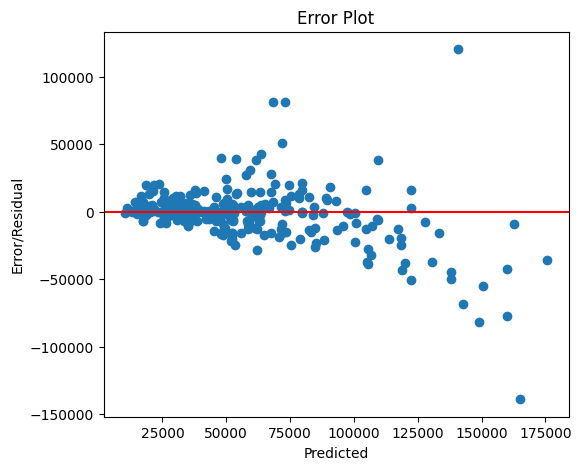

In [57]:
plt.figure(figsize=(6,5))

plt.scatter(y_test_pred, errors)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted")

plt.ylabel("Error/Residual")

plt.title("Error Plot")

plt.show()

### Plot Actual vs Predicted

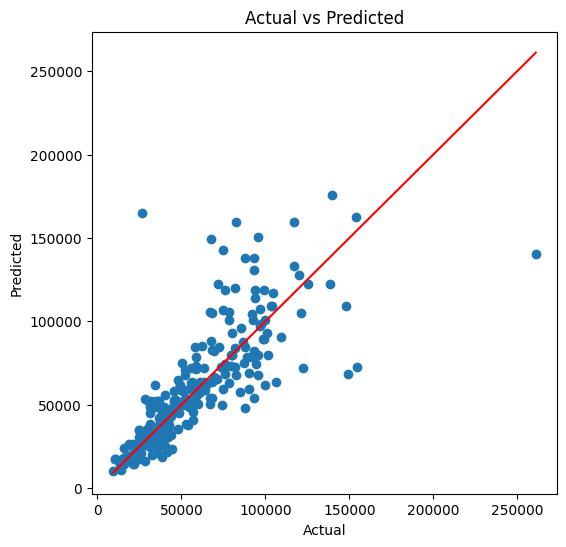

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(ytest, y_test_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    color="red"
)

plt.show()

### visualize the tree

In [63]:
tree = pipe.named_steps['model']

In [66]:
# from sklearn.tree import plot_tree

# plt.figure(figsize=(25,12))

# plot_tree(
#     tree,
#     filled=True,
#     rounded=True,
#     fontsize=8
# )

# plt.show()

## next  hyper parameter tuning

# Overfitting rULE: 

|Training R²	|Testing R²	|Conclusion|
|-|-|-|
|0.99	|        0.98|	Excellent model|
0.95	 |       0.92|	Good model|
0.90	|        0.85|	Acceptable model|
0.99	|        0.55|	Overfitting ❌|
0.60	|        0.58|	Underfitting (or both low)|
0.40	|        0.35|	Poor model|